In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from scipy.stats import norm
from pd_estim_A.eval.eval_df_build import build_evaluation_dataframe
from pd_estim_A.eval.evaluation_frequentist import jb_panel_on_returns

model_data_dir = Path("../data/derived")

merton = pd.read_csv(model_data_dir / "merton_weekly.csv")
nig = pd.read_csv(model_data_dir / "nig_em_weekly.csv")
cds = pd.read_csv(model_data_dir / "CDS_panel.csv")

eval_df = build_evaluation_dataframe(
    derived_dir=model_data_dir,
    rf_path="../data/raw/ecb_yc_1y_aaa.csv",
    recovery=0.40,
    cds_unit="auto",
    require_both_models=True,
)

print(merton.keys())
print(nig.keys())
print(cds.keys())
print(eval_df.keys())

Index(['gvkey', 'date', 'sigma_hat', 'mu_hat', 'V_0', 'V_used', 'B_used',
       'PD_Q', 'PD_P', 'train_start_date', 'train_end_date', 'training_end'],
      dtype='object')
Index(['date', 'window_idx', 'ok', 'msg', 'window_train_start',
       'window_train_end', 'window_oos_start', 'window_oos_end', 'gvkey',
       'A_hat_oos', 'theta_oos', 'L_proxy', 'PD_P', 'PD_Q', 'alpha', 'beta1',
       'delta', 'beta0', 'em_converged', 'em_n_iter'],
      dtype='object')
Index(['gvkey', 'date', 'cds'], dtype='object')
Index(['gvkey', 'date', 'PD_1y_Merton_Q', 'PD_1y_Merton_P', 'PD_1y_NIG_Q',
       'PD_1y_NIG_P', 'cds', 'r_f', 'lambda_CDS_triangle',
       'PD_1y_CDS_triangle', 'lambda_CDS_par', 'PD_1y_CDS_par', 'gvkey_x',
       'gvkey_y'],
      dtype='object')


#### Jarque_Brera Test for Non-Normality Assumption (specific)

note: the goal here is rejection of normality, can't prove that NIG fit is accurate

In [3]:
# Merton
jb_merton = jb_panel_on_returns(
    merton,
    value_col="V_used",
    id_col="gvkey",
    date_col="date",
    min_obs=30,
    value_is_return=False,
    log_returns=True,
)

# NIG
nig_jb_input = nig.copy()
if "ok" in nig_jb_input.columns:
    nig_jb_input = nig_jb_input.loc[nig_jb_input["ok"].fillna(False)].copy()

jb_nig = jb_panel_on_returns(
    nig_jb_input,
    value_col="A_hat_oos",
    id_col="gvkey",
    date_col="date",
    min_obs=30,
    value_is_return=False,
    log_returns=True,
)

display(jb_merton["summary"])
display(jb_nig["summary"])

display(jb_merton["by_firm"])
display(jb_nig["by_firm"])

jb_compare = (
    jb_merton["by_firm"]
    .rename(columns={
        "n": "n_merton",
        "skewness": "skew_merton",
        "kurtosis": "kurt_merton",
        "excess_kurtosis": "exkurt_merton",
        "JB": "JB_merton",
        "p_value": "p_merton",
        "reject_5pct": "reject_merton_5pct",
    })
    .merge(
        jb_nig["by_firm"].rename(columns={
            "n": "n_nig",
            "skewness": "skew_nig",
            "kurtosis": "kurt_nig",
            "excess_kurtosis": "exkurt_nig",
            "JB": "JB_nig",
            "p_value": "p_nig",
            "reject_5pct": "reject_nig_5pct",
        }),
        on="gvkey",
        how="outer",
    )
)

display(jb_compare.sort_values("p_merton"))
display(jb_compare.sort_values("p_nig"))

print("Merton pooled JB summary:")
print(jb_merton["summary"].iloc[0].to_dict())

print("\nNIG pooled JB summary:")
print(jb_nig["summary"].iloc[0].to_dict())

,value_col,series_tested,n_firms_total,n_firms_tested,share_reject_5pct,mean_skewness,mean_excess_kurtosis,median_excess_kurtosis,pooled_JB,pooled_p_value,pooled_reject_5pct,n_returns_pooled
0,V_used,log returns from levels,36,36,1.0,1.035425,21.471194,8.510459,355256.103181,0.0,True,21024


,value_col,series_tested,n_firms_total,n_firms_tested,share_reject_5pct,mean_skewness,mean_excess_kurtosis,median_excess_kurtosis,pooled_JB,pooled_p_value,pooled_reject_5pct,n_returns_pooled
0,A_hat_oos,log returns from levels,21,21,1.0,0.463847,33.1921,19.15676,5.697394e+06,0.0,True,10582


,gvkey,n,skewness,kurtosis,excess_kurtosis,JB,p_value,reject_5pct
0,221616,584,7.733106,124.956450,121.956450,367739.431706,0.000000e+00,True
1,243774,584,3.719520,88.585551,85.585551,179585.496374,0.000000e+00,True
2,241637,584,4.887291,79.697331,76.697331,145465.229341,0.000000e+00,True
3,23667,584,6.044138,77.287355,74.287355,137841.946106,0.000000e+00,True
4,100080,584,4.425577,70.322698,67.322698,112193.423396,0.000000e+00,True
5,201794,584,2.352530,62.005342,59.005342,85258.354782,0.000000e+00,True
6,101248,584,3.436399,45.844987,42.844987,45817.921108,0.000000e+00,True
7,23671,584,1.587746,29.242784,26.242784,17003.341427,0.000000e+00,True
8,61616,584,1.230348,29.315887,26.315887,16998.803143,0.000000e+00,True
9,24625,584,1.241614,22.583362,19.583362,9482.078819,0.000000e+00,True


,gvkey,n,skewness,kurtosis,excess_kurtosis,JB,p_value,reject_5pct
0,100080,560,-0.092165,138.173592,135.173592,426345.126249,0.000000e+00,True
1,101361,482,0.023871,119.341343,116.341343,271834.149692,0.000000e+00,True
2,61616,482,0.009377,81.030987,78.030987,122284.108052,0.000000e+00,True
3,23667,521,5.890340,72.831353,69.831353,108871.681290,0.000000e+00,True
4,101202,495,0.029399,61.825919,58.825919,71372.650715,0.000000e+00,True
5,220940,378,0.007022,48.483423,45.483423,32582.685343,0.000000e+00,True
6,23671,560,1.579970,28.411060,25.411060,15299.834342,0.000000e+00,True
7,221616,418,0.405745,30.704107,27.704107,13379.066866,0.000000e+00,True
8,201794,278,0.810856,35.704554,32.704554,12419.856591,0.000000e+00,True
9,100957,521,-0.051036,23.078231,20.078231,8751.623017,0.000000e+00,True


,gvkey,n_merton,skew_merton,kurt_merton,exkurt_merton,JB_merton,p_merton,reject_merton_5pct,n_nig,skew_nig,kurt_nig,exkurt_nig,JB_nig,p_nig,reject_nig_5pct
17,101248,584,3.436399,45.844987,42.844987,45817.921108,0.000000e+00,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,201794,584,2.352530,62.005342,59.005342,85258.354782,0.000000e+00,True,278.0,0.810856,35.704554,32.704554,12419.856591,0.000000e+00,True
18,101305,584,-0.520157,10.796329,7.796329,1505.381527,0.000000e+00,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
34,243774,584,3.719520,88.585551,85.585551,179585.496374,0.000000e+00,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
15,101202,584,0.665500,12.712825,9.712825,2338.689403,0.000000e+00,True,495.0,0.029399,61.825919,58.825919,71372.650715,0.000000e+00,True
27,220833,584,-0.372312,11.162659,8.162659,1634.797752,0.000000e+00,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
28,220940,584,0.522885,11.673622,8.673622,1857.250367,0.000000e+00,True,378.0,0.007022,48.483423,45.483423,32582.685343,0.000000e+00,True
12,100312,584,1.353308,11.347295,8.347295,1873.742236,0.000000e+00,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN
11,100080,584,4.425577,70.322698,67.322698,112193.423396,0.000000e+00,True,560.0,-0.092165,138.173592,135.173592,426345.126249,0.000000e+00,True
22,103487,584,-1.277944,14.469646,11.469646,3360.076457,0.000000e+00,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,gvkey,n_merton,skew_merton,kurt_merton,exkurt_merton,JB_merton,p_merton,reject_merton_5pct,n_nig,skew_nig,kurt_nig,exkurt_nig,JB_nig,p_nig,reject_nig_5pct
15,101202,584,0.665500,12.712825,9.712825,2338.689403,0.000000e+00,True,495.0,0.029399,61.825919,58.825919,71372.650715,0.000000e+00,True
30,221616,584,7.733106,124.956450,121.956450,367739.431706,0.000000e+00,True,418.0,0.405745,30.704107,27.704107,13379.066866,0.000000e+00,True
28,220940,584,0.522885,11.673622,8.673622,1857.250367,0.000000e+00,True,378.0,0.007022,48.483423,45.483423,32582.685343,0.000000e+00,True
24,201794,584,2.352530,62.005342,59.005342,85258.354782,0.000000e+00,True,278.0,0.810856,35.704554,32.704554,12419.856591,0.000000e+00,True
21,102296,584,0.266608,13.237712,10.237712,2557.313458,0.000000e+00,True,534.0,0.354129,12.808957,9.808957,2151.959204,0.000000e+00,True
20,101361,584,-0.569922,6.441164,3.441164,319.760826,3.671291e-70,True,482.0,0.023871,119.341343,116.341343,271834.149692,0.000000e+00,True
19,101336,584,-0.442929,5.645399,2.645399,189.383419,7.514726e-42,True,508.0,0.678361,12.801283,9.801283,2072.340160,0.000000e+00,True
14,100957,584,0.268248,5.764079,2.764079,192.913777,1.286191e-42,True,521.0,-0.051036,23.078231,20.078231,8751.623017,0.000000e+00,True
32,241456,584,1.384137,18.892764,15.892764,6332.586556,0.000000e+00,True,534.0,0.710751,21.278455,18.278455,7478.727281,0.000000e+00,True
10,100022,584,1.955146,19.167603,16.167603,6732.590127,0.000000e+00,True,404.0,0.182837,22.156760,19.156760,6179.772235,0.000000e+00,True


Merton pooled JB summary:
{'value_col': 'V_used', 'series_tested': 'log returns from levels', 'n_firms_total': 36, 'n_firms_tested': 36, 'share_reject_5pct': 1.0, 'mean_skewness': 1.0354254714458626, 'mean_excess_kurtosis': 21.471193975931072, 'median_excess_kurtosis': 8.510458627465564, 'pooled_JB': 355256.1031806884, 'pooled_p_value': 0.0, 'pooled_reject_5pct': True, 'n_returns_pooled': 21024}

NIG pooled JB summary:
{'value_col': 'A_hat_oos', 'series_tested': 'log returns from levels', 'n_firms_total': 21, 'n_firms_tested': 21, 'share_reject_5pct': 1.0, 'mean_skewness': 0.463846888352666, 'mean_excess_kurtosis': 33.19210016820567, 'median_excess_kurtosis': 19.15676028480849, 'pooled_JB': 5697393.980452653, 'pooled_p_value': 0.0, 'pooled_reject_5pct': True, 'n_returns_pooled': 10582}


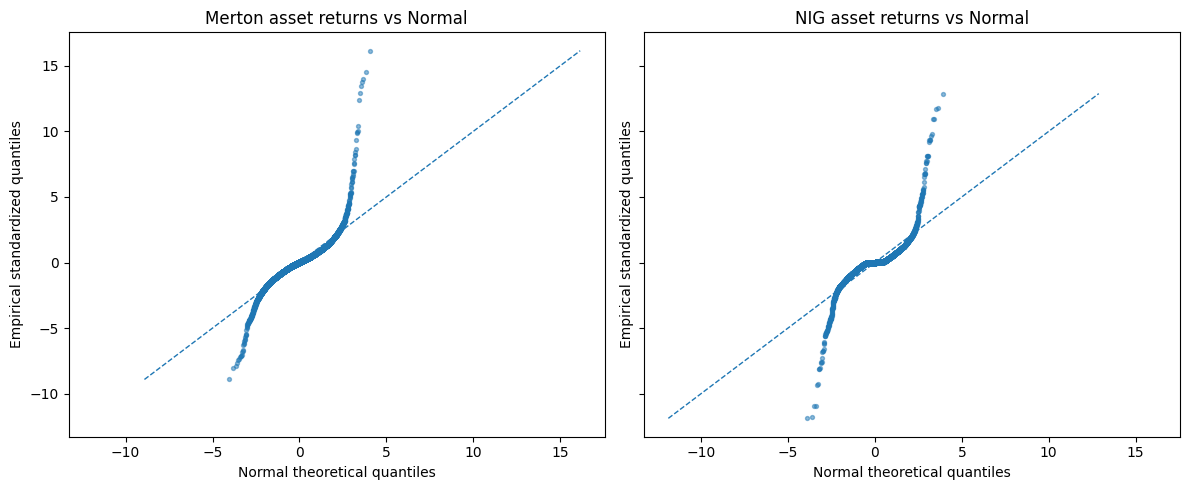

In [4]:
#plots
def pooled_standardized_returns(ret_panel, id_col="gvkey", ret_col="ret"):
    z = ret_panel.copy()
    z[ret_col] = pd.to_numeric(z[ret_col], errors="coerce")
    z = z.dropna(subset=[id_col, ret_col]).copy()

    z["z"] = z.groupby(id_col)[ret_col].transform(
        lambda s: (s - s.mean()) / s.std(ddof=1) if s.std(ddof=1) > 0 else np.nan
    )
    z = z.dropna(subset=["z"]).copy()
    return z["z"].to_numpy()

z_m = pooled_standardized_returns(jb_merton["returns_panel"])
z_n = pooled_standardized_returns(jb_nig["returns_panel"])

def qq_xy(z):
    z = np.sort(np.asarray(z, dtype=float))
    n = len(z)
    p = (np.arange(1, n + 1) - 0.5) / n
    q_theory = norm.ppf(p)
    return q_theory, z

qm_x, qm_y = qq_xy(z_m)
qn_x, qn_y = qq_xy(z_n)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True, sharey=True)

for ax, x, y, title in [
    (axes[0], qm_x, qm_y, "Merton asset returns vs Normal"),
    (axes[1], qn_x, qn_y, "NIG asset returns vs Normal"),
]:
    lo = min(x.min(), y.min())
    hi = max(x.max(), y.max())
    ax.scatter(x, y, s=8, alpha=0.5)
    ax.plot([lo, hi], [lo, hi], "--", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel("Normal theoretical quantiles")
    ax.set_ylabel("Empirical standardized quantiles")

plt.tight_layout()
plt.show()

#### KS Test
design is:
- choose 4–5 quarters by ex ante regime criteria
- for each quarter, use the parameter vector fixed for that quarter
- run KS on the associated training window (104 weeks)

In [ ]:
# quarter choice criteria from cds
eval_df["date"] = pd.to_datetime(eval_df["date"])
q_cds = (
    eval_df.assign(quarter=eval_df["date"].dt.to_period("Q").astype(str))
           .groupby("quarter")
           .agg(
               cds_med=("PD_1y_CDS_par", "median"),
               cds_p90=("PD_1y_CDS_par", lambda s: s.quantile(0.90)),
               n_obs=("gvkey", "size"),
           )
           .sort_index()
)

display(q_cds)

selected_quarters = ["2019Q4", "2020Q2", "2021Q4", "2022Q3", "2024Q2"]
selected_quarters

,cds_med,cds_p90,n_obs
quarter,,,
2014Q2,0.001311,0.006713,192
2014Q3,0.001283,0.003838,208
2014Q4,0.001531,0.004155,234
2015Q1,0.001260,0.003551,234
2015Q2,0.001672,0.004155,247
2015Q3,0.002525,0.004979,234
2015Q4,0.002435,0.004767,273
2016Q1,0.003393,0.005709,273
2016Q2,0.002479,0.004680,273


['2018Q2', '2020Q2', '2021Q4', '2022Q3', '2024Q2']

In [12]:
from importlib import reload
import pd_estim_A.eval.evaluation_frequentist as evf

#  Merton uses a 2-year weekly window -> 104 (needed as start date not always defined)
ks_merton = evf.ks_fixed_normal_by_quarter(
    param_df=merton,
    level_df=merton,
    selected_quarters=selected_quarters,
    level_col="V_used",
    mu_col="mu_hat",
    sigma_col="sigma_hat",
    train_end_col="train_end_date",
    train_start_col=None,
    merton_lookback_weeks=104,
    id_col="gvkey",
    date_col="date",
    min_obs=20,
)

ks_nig = evf.ks_fixed_nig_by_quarter(
    param_df=nig,
    level_df=nig,
    selected_quarters=selected_quarters,
    level_col="A_hat_oos",
    alpha_col="alpha",
    beta_col="beta1",
    delta_col="delta",
    mu_col="beta0",
    train_start_col="window_train_start",
    train_end_col="window_train_end",
    id_col="gvkey",
    date_col="date",
    ok_col="ok",
    min_obs=20,
)

display(ks_merton["by_quarter"])
display(ks_nig["by_quarter"])

display(ks_merton["by_firm_quarter"].head(20))
display(ks_nig["by_firm_quarter"].head(20))

,quarter,n_firms,mean_n_obs,mean_KS_D,median_KS_D,share_reject_5pct
0,2018Q2,36,103.0,0.656773,0.653750,1.0
1,2020Q2,36,108.0,0.599762,0.600812,1.0
2,2021Q4,36,111.0,0.593790,0.561872,1.0
3,2022Q3,36,110.0,0.566421,0.530564,1.0
4,2024Q2,36,103.0,0.620515,0.582330,1.0


,quarter,n_firms,mean_n_obs,mean_KS_D,median_KS_D,share_reject_5pct
0,2018Q2,20,100.300000,0.577955,0.546820,1.0
1,2020Q2,19,92.052632,0.579717,0.580351,1.0
2,2021Q4,21,92.476190,0.542241,0.510380,1.0
3,2022Q3,19,98.263158,0.527846,0.498555,1.0
4,2024Q2,17,100.176471,0.571991,0.558472,1.0


,gvkey,quarter,n_obs,train_start,train_end,mu_hat,sigma_hat,KS_D,KS_p_value,reject_5pct
0,100022,2018Q2,103,2016-07-02,2018-06-30,0.046235,0.072490,0.633197,1.439876e-40,True
1,100080,2018Q2,103,2016-07-02,2018-06-30,0.020556,0.139799,0.434610,3.297502e-18,True
2,100312,2018Q2,103,2016-07-02,2018-06-30,0.126543,0.107499,0.804531,1.443807e-72,True
3,100581,2018Q2,103,2016-07-02,2018-06-30,0.102570,0.131307,0.668351,7.074186e-46,True
4,100957,2018Q2,103,2016-07-02,2018-06-30,0.039449,0.069795,0.598812,7.867825e-36,True
5,101202,2018Q2,103,2016-07-02,2018-06-30,0.199165,0.181270,0.785763,4.089177e-68,True
6,101204,2018Q2,103,2016-07-02,2018-06-30,-0.042130,0.123164,0.508793,3.035139e-25,True
7,101248,2018Q2,103,2016-07-02,2018-06-30,0.009255,0.145094,0.385360,2.835713e-14,True
8,101305,2018Q2,103,2016-07-02,2018-06-30,0.157508,0.118399,0.828876,6.752709e-79,True
9,101336,2018Q2,103,2016-07-02,2018-06-30,0.078631,0.126596,0.620882,8.016984e-39,True


,gvkey,quarter,n_obs,train_start,train_end,alpha,beta,delta,mu,KS_D,KS_p_value,reject_5pct
0,100080,2018Q2,104,2016-04-01,2018-03-30,74.797525,-5.777290,1.756891,0.102371,0.451230,7.514708e-20,True
1,100957,2018Q2,104,2016-04-01,2018-03-30,358.662816,104.680838,1.574258,-0.477166,0.335542,6.056620e-11,True
2,101202,2018Q2,104,2016-04-01,2018-03-30,79.474778,25.575962,1.088700,-0.297558,0.577372,2.125629e-33,True
3,101204,2018Q2,104,2016-04-01,2018-03-30,71.578065,-4.736757,1.415707,0.052179,0.493534,6.610162e-24,True
4,101336,2018Q2,104,2016-04-01,2018-03-30,22524.589935,-22298.561248,1.111913,7.869841,0.623586,1.412703e-39,True
5,101361,2018Q2,104,2016-04-01,2018-03-30,55.239451,-18.477379,0.740296,0.318580,0.548543,6.687285e-30,True
6,102296,2018Q2,104,2016-04-01,2018-03-30,151.977285,-13.921549,1.123702,0.147844,0.571754,1.070177e-32,True
7,14447,2018Q2,104,2016-04-01,2018-03-30,120.373658,47.685403,1.939951,-0.652141,0.800398,3.012303e-72,True
8,17436,2018Q2,104,2016-04-01,2018-03-30,1403.189471,-938.829426,8.634274,7.842619,0.585304,2.083272e-34,True
9,17452,2018Q2,104,2016-04-01,2018-03-30,204.758691,-17.917746,2.107884,0.210770,0.449895,9.920240e-20,True


In [13]:
ks_cmp = (
    ks_merton["by_firm_quarter"]
    .rename(columns={
        "KS_D": "KS_D_merton",
        "KS_p_value": "KS_p_merton",
        "reject_5pct": "reject_merton_5pct",
        "n_obs": "n_obs_merton",
    })
    .merge(
        ks_nig["by_firm_quarter"].rename(columns={
            "KS_D": "KS_D_nig",
            "KS_p_value": "KS_p_nig",
            "reject_5pct": "reject_nig_5pct",
            "n_obs": "n_obs_nig",
        }),
        on=["gvkey", "quarter"],
        how="inner",
    )
)

ks_cmp["D_diff_merton_minus_nig"] = ks_cmp["KS_D_merton"] - ks_cmp["KS_D_nig"]

display(
    ks_cmp.groupby("quarter", as_index=False)
          .agg(
              n_firms=("gvkey", "nunique"),
              mean_D_merton=("KS_D_merton", "mean"),
              mean_D_nig=("KS_D_nig", "mean"),
              mean_diff=("D_diff_merton_minus_nig", "mean"),
              share_merton_reject=("reject_merton_5pct", "mean"),
              share_nig_reject=("reject_nig_5pct", "mean"),
          )
)

display(ks_cmp.sort_values(["quarter", "D_diff_merton_minus_nig"], ascending=[True, False]))

,quarter,n_firms,mean_D_merton,mean_D_nig,mean_diff,share_merton_reject,share_nig_reject
0,2018Q2,20,0.641026,0.577955,0.063071,1.0,1.0
1,2020Q2,19,0.615714,0.579717,0.035996,1.0,1.0
2,2021Q4,21,0.591978,0.542241,0.049738,1.0,1.0
3,2022Q3,19,0.552113,0.527846,0.024268,1.0,1.0
4,2024Q2,17,0.579784,0.571991,0.007792,1.0,1.0


,gvkey,quarter,n_obs_merton,train_start_x,train_end_x,mu_hat,sigma_hat,KS_D_merton,KS_p_merton,reject_merton_5pct,...,train_start_y,train_end_y,alpha,beta,delta,mu,KS_D_nig,KS_p_nig,reject_nig_5pct,D_diff_merton_minus_nig
1,100957,2018Q2,103,2016-07-02,2018-06-30,0.039449,0.069795,0.598812,7.867825e-36,True,...,2016-04-01,2018-03-30,358.662816,104.680838,1.574258,-0.477166,0.335542,6.056620e-11,True,0.263270
2,101202,2018Q2,103,2016-07-02,2018-06-30,0.199165,0.181270,0.785763,4.089177e-68,True,...,2016-04-01,2018-03-30,79.474778,25.575962,1.088700,-0.297558,0.577372,2.125629e-33,True,0.208391
9,17452,2018Q2,103,2016-07-02,2018-06-30,0.091566,0.157172,0.629459,4.946035e-40,True,...,2016-04-01,2018-03-30,204.758691,-17.917746,2.107884,0.210770,0.449895,9.920240e-20,True,0.179563
17,23671,2018Q2,103,2016-07-02,2018-06-30,0.176916,0.283452,0.642346,6.674354e-42,True,...,2016-04-01,2018-03-30,50.432230,2.046316,1.232580,-0.092669,0.464286,4.709714e-21,True,0.178060
5,101361,2018Q2,103,2016-07-02,2018-06-30,0.101099,0.115997,0.715382,7.802238e-54,True,...,2016-04-01,2018-03-30,55.239451,-18.477379,0.740296,0.318580,0.548543,6.687285e-30,True,0.166838
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
88,17452,2024Q2,103,2022-07-03,2024-06-30,0.019306,0.080565,0.466415,4.700565e-21,True,...,2022-04-01,2024-03-29,262.955266,-48.419874,1.943555,0.399973,0.535057,2.370349e-28,True,-0.068642
93,23671,2024Q2,103,2022-07-03,2024-06-30,-0.095787,0.154708,0.592903,4.659440e-35,True,...,2022-04-01,2024-03-29,32.286554,-8.855498,0.772444,0.088795,0.661946,2.655978e-45,True,-0.069043
92,23667,2024Q2,103,2022-07-03,2024-06-30,0.006648,0.086258,0.403337,1.205206e-15,True,...,2022-04-01,2024-03-29,145.660862,-17.327907,1.197699,0.101058,0.547929,7.889002e-30,True,-0.144592
91,222379,2024Q2,103,2022-07-03,2024-06-30,-0.046354,0.263641,0.467921,3.397348e-21,True,...,2022-04-01,2024-03-29,98.213651,14.848085,5.669366,-1.034224,0.649543,2.187153e-43,True,-0.181622


To assess whether the return distribution assumed by each model is plausible, we used the Kolmogorov–Smirnov test, which measures the largest gap between the empirical distribution of asset log-returns observed in a given training window and the theoretical distribution implied by the model; a smaller KS distance means the model’s distribution is closer to the data. We carried out the KS test separately for a small set of selected quarters. In each quarter, we did not re-estimate a new distribution for the test itself; instead, we used the parameter values that each model had already estimated for that quarter, and compared the model-implied return distribution with the asset returns observed in the corresponding training window. This matches the way our models are built, because both Merton and NIG are estimated on a rolling basis and their parameters change over time. 

The quarters are selected ex ante from the CDS benchmark only, using quarterly cross-sectional median CDS PD and p90 CDS PD:
- calm quarter: the quarter with one of the lowest median CDS PDs, here it is 2019Q4
- acute stress quarter: the quarter with the largest jump or major spike in median/p90 CDS PD. Here 2020Q2
- recovery quarter: a quarter 2–4 quarters after the stress peak where median/p90 CDS PD have fallen back. 
- Post-covid - normalization period 2021Q4.
- non-COVID stress quarter: the largest later local peak, especially in p90 CDS PD, 2022Q3.
- recent quarter: one quarter from the final year of the sample (i.e. 2024Q2)

In short, we pick quarters that span distinct credit regimes identified only from quarterly CDS distribution summaries, not from model fit.

Across all selected quarters, both models are formally rejected at the 5% level, so the p-values do not distinguish them; the informative object is the KS distance itself. On the common firm-quarter sample, the NIG model has a lower average KS distance in every regime considered, showing that the empirical asset-return distribution is consistently closer to the fitted NIG law than to the fitted Normal law (Table (!!!!)). The implication is clear: even though neither specification is perfect, the Gaussian assumption of the classical Merton model is systematically less adequate, while the fat-tailed NIG specification provides a better description of the return behavior that matters for default-risk modelling.